# Benard Convection with MIDL

Use the Benard dataset in this folder and run `MIDL` to discover dominant dimensionless groups.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

current_notebook_dir = os.getcwd()
project_root_dir = os.path.abspath(os.path.join(current_notebook_dir, '..', '..'))
if project_root_dir not in sys.path:
    sys.path.append(project_root_dir)

import midl
MIDL = midl.MIDL
calc_basis = midl.calc_basis


In [2]:
# Load Benard dataset and define variables
df = pd.read_csv('dataset_rb.csv')
data = df.iloc[:, 2:12].to_numpy()

Nu = (data[:, 0] * data[:, 1]) / (data[:, 3] * data[:, 2])
Y = Nu

# h, delta_T, lambda, g, alpha, nu, kappa
X_raw = data[:, [1, 2, 3, 4, 5, 6, 7]]
variables = ['h', 'delta_T', 'lambda', 'g', 'alpha', 'nu', 'kappa']

D_in = np.array([
    [1, 0, 1, 1, 0, 2, 2],
    [0, 0, -3, -2, 0, -1, -1],
    [0, 0, 1, 0, 0, 0, 0],
    [0, 1, -1, 0, -1, 0, 0],
], dtype=float)

print('D_in rank:', np.linalg.matrix_rank(D_in))


D_in rank: 4


In [3]:
# Compute basis and construct independent dimensionless groups Pi
basis, r = calc_basis(D_in)
print('Null space dimension:', D_in.shape[1] - r)
print('basis:\n', basis)

Pi = np.exp(np.log(X_raw) @ basis)


Null space dimension: 3
basis:
 [[-1.06269166e-02 -6.12326330e-01 -6.12326330e-01]
 [ 7.07053543e-01 -6.13545314e-03 -6.13545314e-03]
 [-4.74875048e-17 -2.42940650e-17 -2.42940650e-17]
 [-3.54230552e-03 -2.04108777e-01 -2.04108777e-01]
 [ 7.07053543e-01 -6.13545314e-03 -6.13545314e-03]
 [ 3.54230552e-03  7.04108777e-01 -2.95891223e-01]
 [ 3.54230552e-03 -2.95891223e-01  7.04108777e-01]]


In [4]:
# Run MIDL
model = MIDL(
    k_neighbors=6,
    de_maxiter=400,
    random_state=42,
)

result = model.fit(Pi_independent=Pi, pi_dependent=Y, threshold=5)
pi_hat = MIDL.compose_new_pi(Pi, result['W'])

print('\n=== MIDL Results ===')
print('MI scores:', result['mi_scores'])
print('dominant_q:', result['dominant_q'])
print('drop ratios I_i / I_(i+1):', result['drop_ratios'])

# Exponents in original variable space
alpha = basis @ result['W']
print('\n=== Recovered exponents in original variables ===')
print(alpha)


[Step 1] MI = 1.991301
[Step 2] MI = 1.115576
   ratio = 1.785
[Step 3] MI = 0.405103
   ratio = 2.754

=== MIDL Results ===
MI scores: [1.99130105 1.1155764  0.40510313]
dominant_q: 3
drop ratios I_i / I_(i+1): None

=== Recovered exponents in original variables ===
[[-7.82296725e-01 -1.29375512e-01  3.48243896e-01]
 [-2.85335632e-01 -1.56440151e-02 -6.46791189e-01]
 [-1.25684944e-17 -4.17804989e-18  5.70967875e-17]
 [-2.60765575e-01 -4.31251705e-02  1.16081299e-01]
 [-2.85335632e-01 -1.56440151e-02 -6.46791189e-01]
 [ 1.57850726e-01  7.42122011e-01 -8.75865436e-02]
 [ 3.63680424e-01 -6.55871670e-01 -1.44576054e-01]]


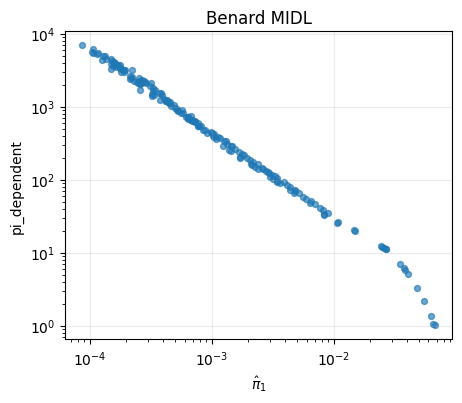

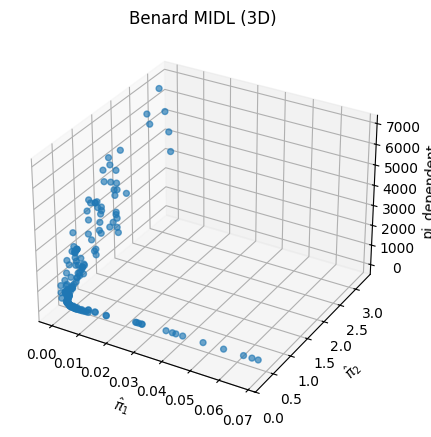

In [5]:
# Plot: 2D always, and extra 3D when dominant_q >= 2
if result['dominant_q'] >= 2:
    ax2d, ax3d = MIDL.plot_component_vs_dependent(
        Pi_independent=Pi,
        pi_dependent=Y,
        W=result['W'],
        dominant_q=result['dominant_q'],
        component_index=0,
        title='Benard MIDL',
        log_scale=True,
    )
else:
    ax2d = MIDL.plot_component_vs_dependent(
        Pi_independent=Pi,
        pi_dependent=Y,
        W=result['W'],
        dominant_q=result['dominant_q'],
        component_index=0,
        title='Benard MIDL',
        log_scale=True,
    )

plt.show()
